## Unsupervised ML : final

In [1]:
### so based on the research and the patterns
### I am doing the unsupervised ML, by taking only the numerical columns and 
### reducing the dimensionality to 2 features by the help of PCA, and then 
### use the algorithms like kmeans, db scan, hierarichal mean clustering

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Data loading

In [3]:
df = pd.read_csv('../data/numerical-only.csv')
df.drop('Unnamed: 0', axis = 1, inplace = True)
df.head()

,Account_Balance,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Transaction_Amount_boxcox
0,93213.17,7,437.63,3,65,883.17,0.8494,0,5.917374
1,75725.25,13,478.76,4,186,2203.36,0.0959,0,0.860767
2,1588.96,14,50.01,4,226,1909.29,0.8400,0,5.205741
3,76807.20,8,182.48,4,76,1311.86,0.7935,0,11.399354
4,92354.66,14,328.69,4,140,966.98,0.3819,1,5.373048


### using the scaler and the pca

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
scaler = StandardScaler()
pca = PCA(n_components = 2)

In [6]:
df_scaled = scaler.fit_transform(df)
df_pca = pca.fit_transform(df_scaled)

In [7]:
df_pca

array([[ 1.36050014,  0.16756584],
       [ 0.3142308 , -2.11794816],
       [-0.06395897,  0.46277509],
       ...,
       [ 0.18972168,  1.51869894],
       [-0.6008815 ,  1.04173308],
       [ 0.7788334 ,  0.61102711]])

### ------------------cluestering-------------------------

### 1. Kmeans clsutering

In [8]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [9]:
wcss = []
for k in range(1, 12) : 
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

In [10]:
wcss

[101693.61080288677,
 68696.34830926506,
 44883.26362136903,
 35233.627788333855,
 29814.35712581995,
 24558.018946132448,
 21277.54895933217,
 19281.385624682596,
 17440.282402329547,
 15530.836024979075,
 14394.58789494698]

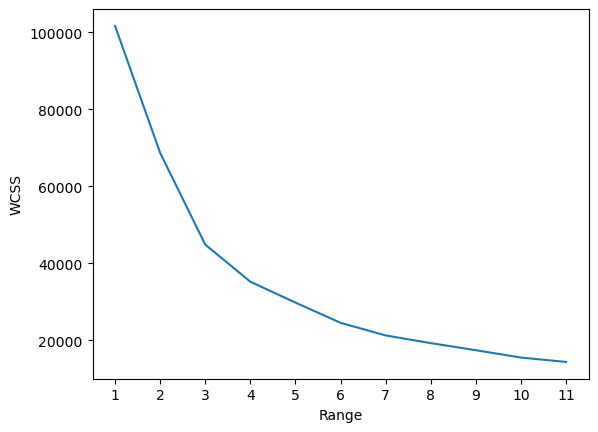

In [11]:
plt.plot(range(1, 12), wcss)
plt.xticks(range(1, 12))
plt.xlabel('Range')
plt.ylabel('WCSS')
plt.show()

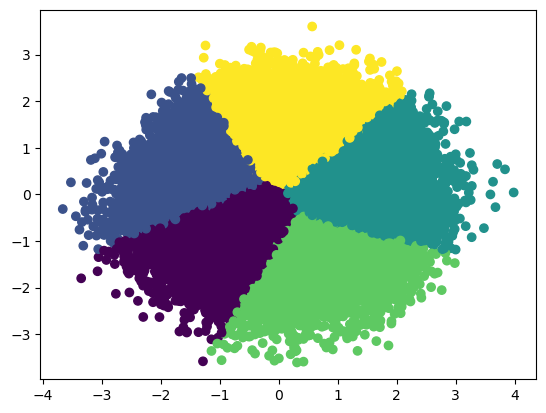

In [12]:
### using k = 5 on the behalf of the wcss score
kmeans = KMeans(n_clusters = 5, init = 'k-means++')
y_labels_kmeans = kmeans.fit_predict(df_pca)
plt.scatter(df_pca[:, 0], df_pca[:, 1], c = y_labels_kmeans)

In [13]:
print(f"silhouette_score : {silhouette_score(df_pca, y_labels_kmeans)}")

silhouette_score : 0.29834111729800394


### 2. DB scan clustering

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [15]:
neigh = NearestNeighbors(n_neighbors = 5)
nbrs = neigh.fit(df_pca)
distances, indices = nbrs.kneighbors(df_pca)
distances = np.sort(distances[:, 4])

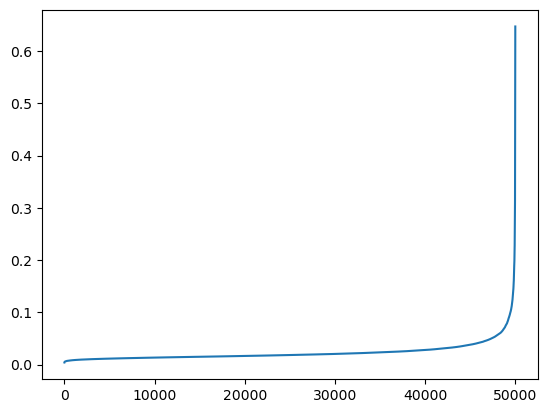

In [16]:
plt.plot(distances)
plt.show()

silhouette_score : 0.48950774910394285


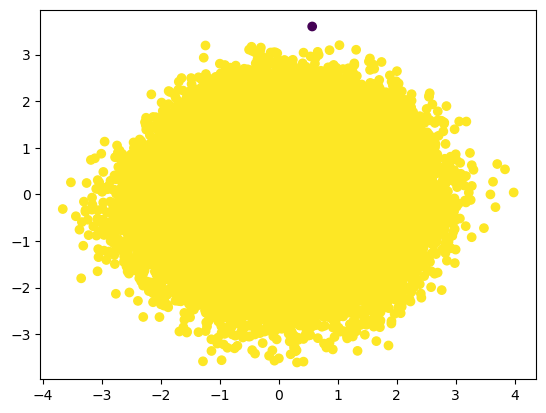

In [101]:
### taking eps = 0.5
db = DBSCAN(eps = 0.5)
y_labels_db = db.fit_predict(df_pca)
print(f"silhouette_score : {silhouette_score(df_pca, y_labels_db)}")
plt.scatter(df_pca[:, 0], df_pca[:, 1], c = y_labels_db)

### 3. Hierarichal mean clustering

In [30]:
### for hierarichal mean clustering, I am gonna take only 1000 samples
### as the dataset is already big enough

In [18]:
df_pca_hm = df_pca[:1000]

In [19]:
print(f"{df_pca.shape} : {df_pca_hm.shape}")

(50000, 2) : (1000, 2)


In [36]:
### Dendogram

Text(0, 0.5, 'euclidian distance')

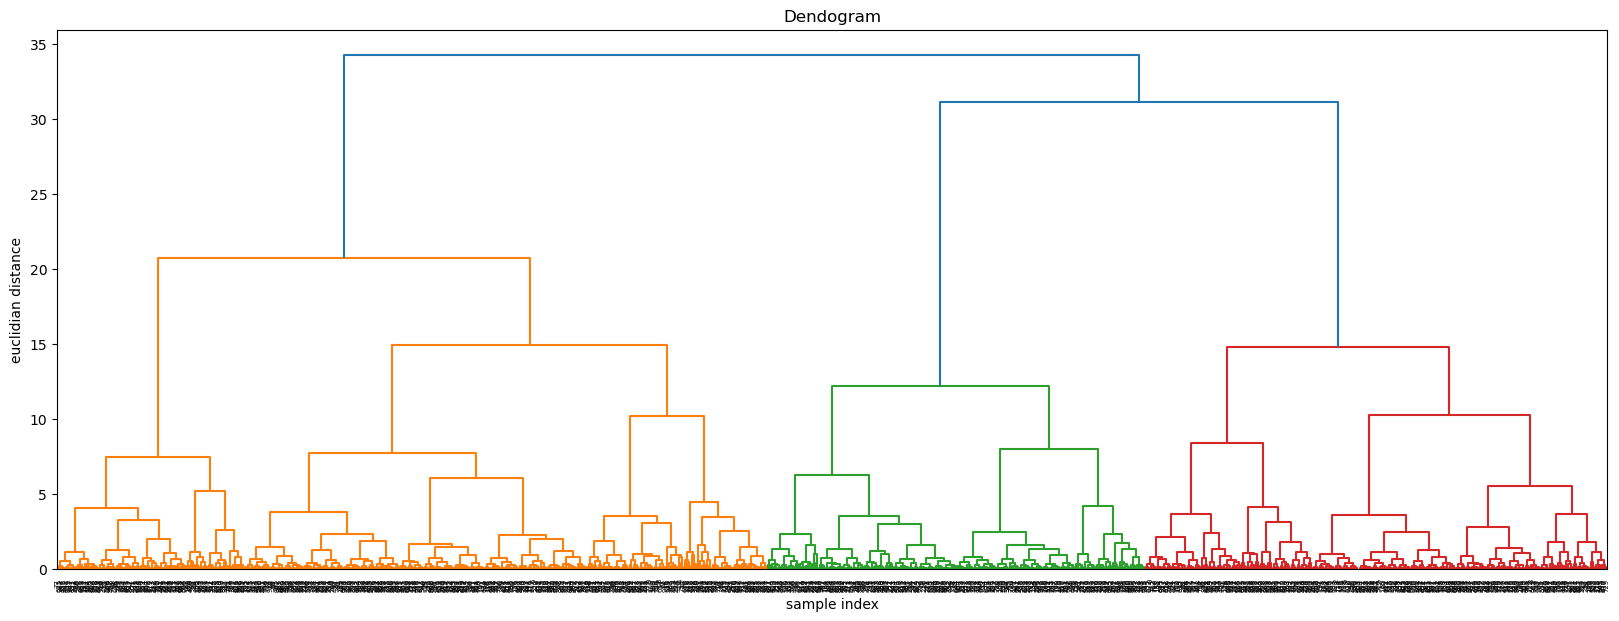

In [20]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(20,7))
plt.title("Dendogram")
sc.dendrogram(sc.linkage(df_pca_hm, method = 'ward'))
plt.title('Dendogram')
plt.xlabel("sample index")
plt.ylabel("euclidian distance")

silhouette_score : 0.5227620253396797


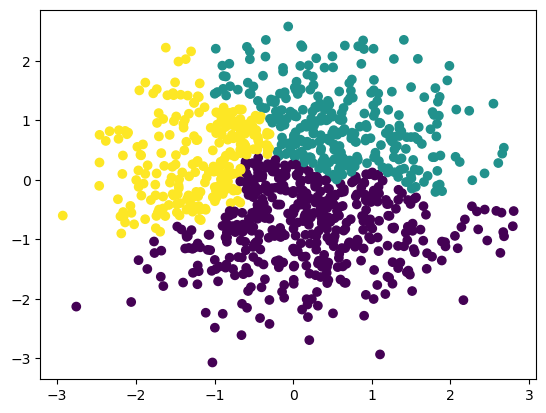

In [21]:
hm = AgglomerativeClustering(n_clusters = 3, linkage = 'ward')
y_labels_hm = hm.fit_predict(df_pca_hm)
print(f"silhouette_score : {silhouette_score(df_pca, y_labels_db)}")
plt.scatter(df_pca_hm[:, 0], df_pca_hm[:, 1], c = y_labels_hm)

### ----------------------------------Anomaly Detection---------------------------------

### 1. Isolation Forest 

In [51]:
### Isolation forest is noramlly used for detecting the global outliers

In [ ]:
### contamination = 0.3
from sklearn.ensemble import IsolationForest

In [85]:
def plot(df_pca, outliers) : 
    plt.figure(figsize = (10, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(df_pca[:, 0], df_pca[:, 1])
    plt.scatter(df_pca[outliers, 0], df_pca[outliers, 1], edgecolors = 'r')
    plt.subplot(1, 2, 2)
    plt.scatter(df_pca[:, 0], df_pca[:, 1])
    plt.show()

In [86]:
cif = IsolationForest(contamination = 0.3)
cif.fit(df_pca)
predictions = cif.predict(df_pca)

In [88]:
outliers = np.where(predictions < 0)

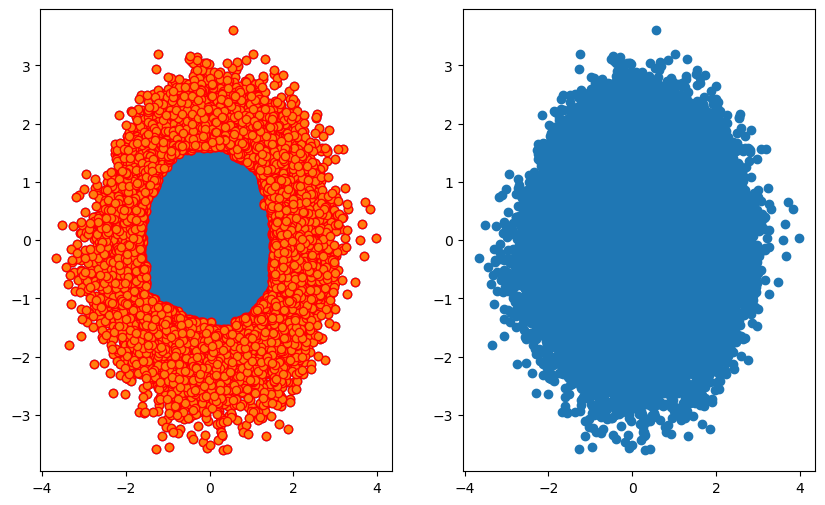

In [89]:
plot(df_pca, outliers)

In [91]:
### contamination = auto
cif = IsolationForest(contamination = 'auto')
cif.fit(df_pca)
predictions = cif.predict(df_pca)
outliers = np.where(predictions < 0)

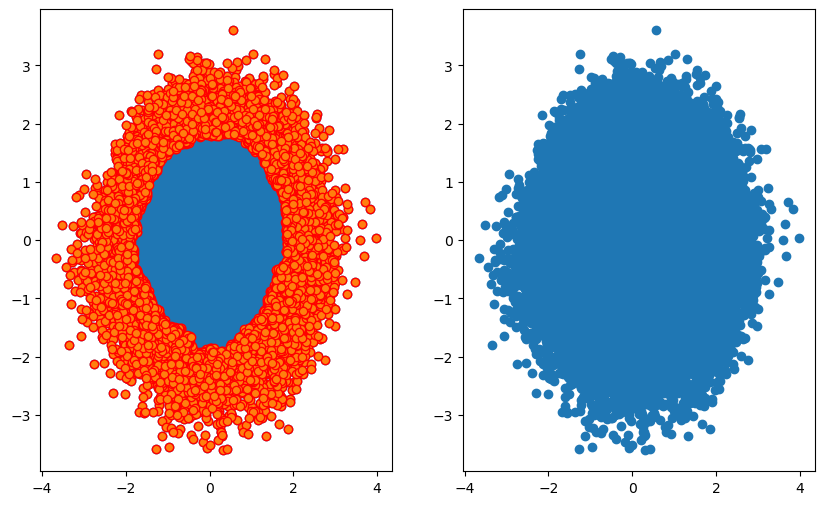

In [92]:
plot(df_pca, outliers)

### selecting the contamination, based on the visuals

In [93]:
cif = IsolationForest(contamination = 'auto', random_state = 42)
cif.fit(df_pca)
scores = cif.score_samples(df_pca)
scores_sorted = np.sort(scores)

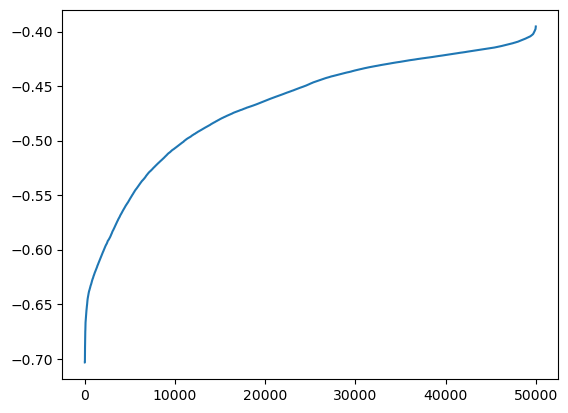

In [94]:
plt.plot(scores_sorted)
plt.show()

In [95]:
scores_sorted

array([-0.70343968, -0.70343968, -0.69652528, ..., -0.39535011,
       -0.39535011, -0.39535011])

In [96]:
### based on the graph, the value for the contamination is 0.02
cif = IsolationForest(contamination = 0.02)
cif.fit(df_pca)
predictions = cif.predict(df_pca)
outliers = np.where(predictions < 0)

In [97]:
values = np.where(scores < -0.63)

In [98]:
print(len(values[0]))

747


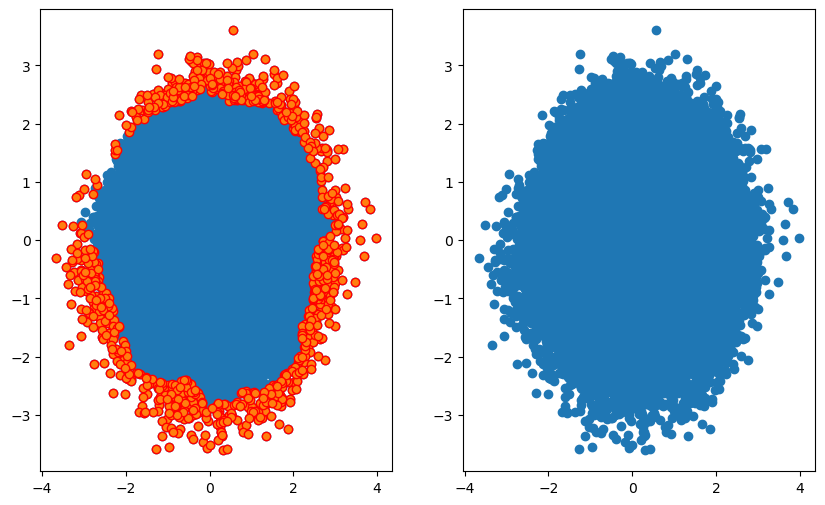

In [99]:
plot(df_pca, outliers)

### 2. LOF (Local outliers)

In [102]:
### we use the Local Outliers factor, from the sklearn.neighbour library
### for detecting the local outliers

In [103]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors = 4, algorithm = 'auto', leaf_size = 30)
local = lof.fit_predict(df_pca)
outliers = np.where(local < 1)

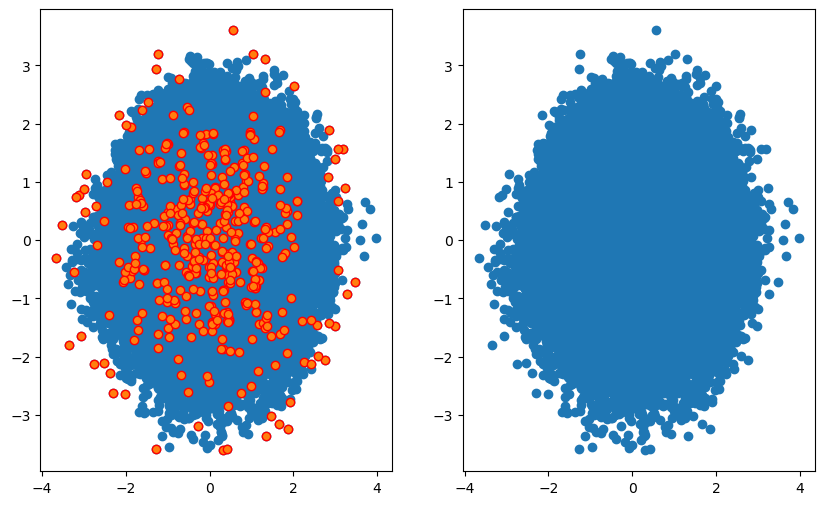

In [104]:
plot(df_pca, outliers)